In [1]:
import h5py 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [2]:
Fs = 5000
ms_to_samples = lambda x: int(x / 1000 * Fs)

In [3]:
seq1 = np.asarray([1,1,1,1,2,1,2,1,2,1,1,2,1,1,1,2,1,1,1,1,1,1,1,2,1,1,1,2,1,1,1,1,2,1,1,2,1,1,2,1])
seq2 = np.asarray([1,2,1,1,1,2,1,1,1,2,1,1,2,1,1,2,1,1,1,1,2,1,1,1,2,1,2,1,1,1,1,1,2,1,1,1,1,2,1,1])
seq3 = np.asarray([1,1,1,1,1,2,1,1,1,2,1,2,1,1,1,2,1,1,2,1,1,1,1,2,1,1,1,2,1,1,2,1,1,2,1,1,1,1,1,2])
seq4 = np.asarray([1,2,1,1,1,1,1,1,2,1,1,2,1,1,2,1,1,1,1,2,1,2,1,1,1,2,1,1,2,1,1,1,1,2,1,2,1,1,1,1])

# 1 - motor, 2 - rest

In [4]:
def calculate_mep_amp(filename_path, bit, seq):
    with h5py.File(filename_path, "r") as h5f:
        data = h5f["eeg/data"][:-1]
    emg = data[:, 0]
    trigger = data[:, -1]
    ttl = np.array(trigger, dtype=np.uint8)
    trigger = ((ttl>>bit) & 0b1).astype(int)
    trigger_diff = np.diff(trigger)
    events = np.where(trigger_diff == 1)[0]
    def cut_epoch(timepoint, data, start, end):
        return data[timepoint+start:timepoint+end]

    start = ms_to_samples(-20)
    end = ms_to_samples(60)
    time = np.linspace(-20, 60, end-start)
    epochs = np.asarray([cut_epoch(timestamp, emg, start, end) for timestamp in events])

    def calculate_mep(epoch, time, from_ms=15, upto_ms=40):
        mask = (time >= from_ms) & (time <= upto_ms)
        if not np.any(mask):
            return np.nan
        data = epoch[mask]
        if data.size == 0 or not np.any(np.isfinite(data)):
            return np.nan
        return float(np.nanmax(data) - np.nanmin(data)) 
    amps = np.asarray([calculate_mep(epoch, time) for epoch in epochs]) * 1e3

    motor_amps = amps[np.where(seq == 1)]
    rest_amps = amps[np.where(seq == 2)]

    print(f"Средняя амплитуда МВП в покое была {np.mean(rest_amps):.3f} мВ. Медиана: {np.median(rest_amps):.3f} мВ.")
    print(f"Средняя амплитуда МВП при движении была {np.mean(motor_amps):.3f} мВ. Медиана: {np.median(motor_amps):.3f} мВ.")

    def baseline_correction(epochs, time, from_ms=-20, to_ms=-5):
        mask = np.where((time > from_ms) & (time<to_ms))[0]
        baseline_mean = np.mean(epochs[:, mask], axis=1)
        return epochs - baseline_mean.reshape((-1, 1))

    bas_epochs = baseline_correction(epochs, time)

    bas_motor_epochs = bas_epochs[np.where(seq == 1)] * 1e3
    bas_rest_epochs = bas_epochs[np.where(seq == 2)] * 1e3

    return bas_motor_epochs, bas_rest_epochs

In [6]:
subject = "03AZ"

# record = "07_tms_68MSO_real.hdf"
# seq = seq1
# filename_path = os.path.join(r"../data", subject, record)
# print(f"-----Испытуемый {subject}, запись {record}-----")
# motor_rmt_real, rest_rmt_real = calculate_mep_amp(filename_path, 2, seq1)


# record = "08_tms_50MSO_real.hdf"
# seq = seq2
# filename_path = os.path.join(r"../data", subject, record)
# print(f"-----Испытуемый {subject}, запись {record}-----")
# motor_quasi_real, rest_quasi_real = calculate_mep_amp(filename_path, 2, seq2)


# record = "09_tms_68MSO_MI.hdf"
# seq = seq3
# filename_path = os.path.join(r"../data", subject, record)
# print(f"-----Испытуемый {subject}, запись {record}-----")
# motor_rmt_mi, rest_rmt_mi = calculate_mep_amp(filename_path, 2, seq3)

record = "11_03AZ_tms_52MSO_MI.hdf"
seq = seq4
filename_path = os.path.join(r"../data", subject, record)
print(f"-----Испытуемый {subject}, запись {record}-----")
motor_quasi_mi, rest_quasi_mi = calculate_mep_amp(filename_path, 2, seq4)


-----Испытуемый 03AZ, запись 11_03AZ_tms_52MSO_MI.hdf-----
Средняя амплитуда МВП в покое была 0.709 мВ. Медиана: 0.662 мВ.
Средняя амплитуда МВП при движении была 0.634 мВ. Медиана: 0.497 мВ.


In [4]:
start = ms_to_samples(-20)
end = ms_to_samples(60)
time = np.linspace(-20, 60, end-start)

In [ ]:
def plot_epochs(time, epochs, label, color):
    mean_epoch = np.mean(epochs, axis=0)
    sem_epoch = np.std(epochs, axis=0) / np.sqrt(epochs.shape[0])
    plt.plot(time, mean_epoch, label=label, color=color)
    plt.fill_between(time, mean_epoch - sem_epoch, mean_epoch + sem_epoch, alpha=0.3, color=color)

def plot_all_epochs(time, motor_epochs, rest_epochs, label_motor, label_rest, title):
    plot_epochs(time, motor_epochs, label_motor, "#961CBB")
    plot_epochs(time, rest_epochs, label_rest, "#4927C5")
    plt.xlabel("Время (мс)")
    plt.ylabel("Амплитуда МВП (мВ)")
    plt.legend()
    plt.title(title)



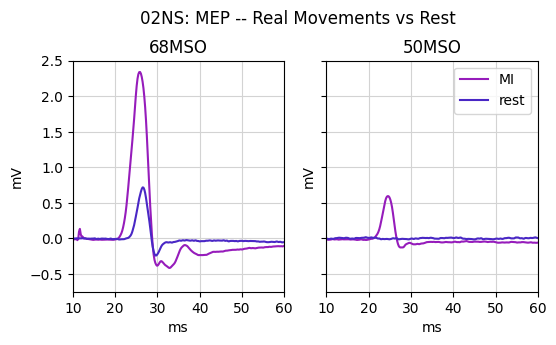

In [215]:
fig, axis = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
ax = axis[0]
ax.plot(time, -np.mean(motor_rmt_real, axis=0), label='MI (n=30)', color="#961CBB")
ax.plot(time, -np.mean(rest_rmt_real, axis=0), label='rest (n=10)', color="#4927C5")
ax.set_title("68MSO")


ax = axis[1]
ax.plot(time, -np.mean(motor_quasi_real, axis=0), label='MI', color="#961CBB")
ax.plot(time, -np.mean(rest_quasi_real, axis=0), label='rest', color="#4927C5")
ax.set_title("50MSO")
ax.legend()
plt.suptitle("02NS: MEP -- Real Movements vs Rest", y=1.05)

for ax in axis:
    ax.set_xlim(10, 60)
    ax.set_xlabel("ms")
    ax.set_ylabel("mV")
    ax.set_ylim(-0.75, 2.5)
    ax.grid(color='lightgrey')

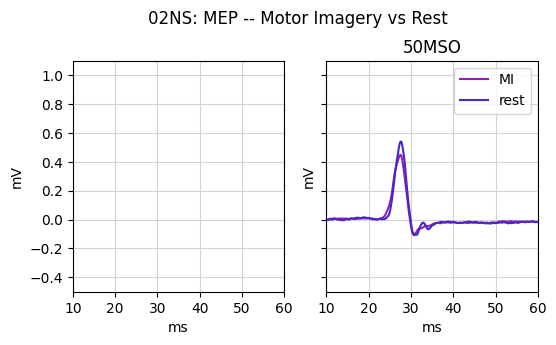

In [9]:
fig, axis = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
# ax = axis[0]
# ax.plot(time, -np.mean(motor_rmt_mi, axis=0), label='MI (n=30)', color="#961CBB")
# ax.plot(time, -np.mean(rest_rmt_mi, axis=0), label='rest (n=10)', color="#4927C5")
# ax.set_title("68MSO")


ax = axis[1]
ax.plot(time, -np.mean(motor_quasi_mi, axis=0), label='MI', color="#961CBB")
ax.plot(time, -np.mean(rest_quasi_mi, axis=0), label='rest', color="#4927C5")
ax.set_title("50MSO")
ax.legend()
plt.suptitle("02NS: MEP -- Motor Imagery vs Rest", y=1.05)

for ax in axis:
    ax.set_xlim(10, 60)
    ax.set_xlabel("ms")
    ax.set_ylabel("mV")
    ax.set_ylim(-0.5, 1.1)
    ax.grid(color='lightgrey')

(120.0, 300.0)

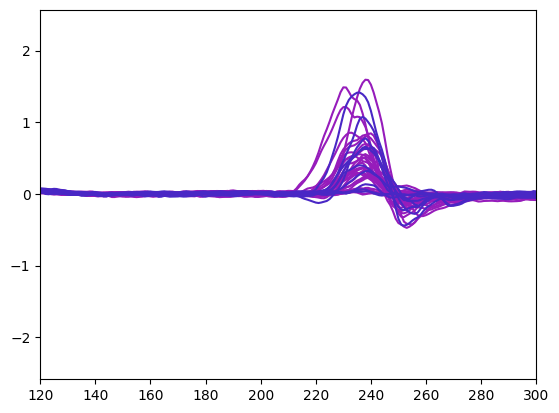

In [18]:
for plot in motor_quasi_mi:
    plt.plot(-plot, label='MI', color="#961CBB");

for plot in rest_quasi_mi:
    plt.plot(-plot, label='rest', color="#4927C5");
plt.xlim(120, 300)

In [13]:
np.mean(motor_quasi_mi, axis=1)

array([-0.03043816, -0.02136143, -0.00607021, -0.02032467, -0.01356255,
       -0.00594018, -0.02025507, -0.02165265, -0.02234028, -0.00336464,
       -0.01185402, -0.00231836, -0.01307882,  0.0011877 , -0.02848842,
       -0.00929453, -0.01140408, -0.01023404, -0.00323965, -0.00941626,
       -0.00822264, -0.00572664, -0.0063471 , -0.01266423, -0.00074247,
       -0.01021889, -0.02163369, -0.01712425, -0.00757093, -0.01482376])

In [ ]:
ax.plot(time, -np.mean(rest_quasi_mi, axis=0), label='rest', color="#4927C5")

In [5]:
filename = r"..\data\04KK\01_04KK_nofb_test.hdf"
# filename = r"..\data\04KK\09_04KK_tms_32MSO_real.hdf"
with h5py.File(filename, "r") as h5f:
    print(h5f["eeg"].keys())
    data = h5f["eeg/data"][:]

<KeysViewHDF5 ['blocks', 'data', 'streamInfo']>


In [23]:
from scipy.signal import iirnotch, tf2sos, butter, sosfilt, sosfilt_zi , sosfiltfilt

sos_filt = butter(N=4, Wn=[5, 90], btype="bandpass", output='sos', fs=Fs)
Q = 50/1
b_notch, a_notch = iirnotch(50, Q, fs=Fs)
sos_notch = tf2sos(b_notch, a_notch)

In [24]:
emg = data[:, 0] *1e3
emg = sosfilt(sos_filt, emg, axis=0)
emg  = sosfilt(sos_notch, emg, axis=0)

trigger = data[:, -1]
ttl = np.array(trigger, dtype=np.uint8)
bit = 4
trigger = ((ttl>>bit) & 0b1).astype(int)
trigger_diff = np.diff(trigger)
events = np.where(trigger_diff == 1)[0]
def cut_epoch(timepoint, data, start, end):
    return data[timepoint+start:timepoint+end]

start = ms_to_samples(-500)
end = ms_to_samples(300)
time = np.linspace(-500, 300, end-start)
emg_epochs = np.asarray([cut_epoch(timestamp, emg, start, end) for timestamp in events])

def baseline_correction(epochs, time, from_ms=-500, to_ms=-400):
    mask = np.where((time > from_ms) & (time<to_ms))[0]
    baseline_mean = np.mean(epochs[:, mask], axis=1)
    return epochs - baseline_mean.reshape((-1, 1))

bas_epochs = baseline_correction(emg_epochs, time)


trig_epochs = np.asarray([cut_epoch(timestamp, trigger, start, end) for timestamp in events])
# # seq 
# # bas_motor_epochs = bas_epochs[np.where(seq == 1)] * 1e3
# # bas_rest_epochs = bas_epochs[np.where(seq == 2)] * 1e3

# trigger_epochs = epochs[:, :, -1]

In [25]:
def calculate_TKEO(x):
    tkeo = np.zeros_like(x)
    tkeo[1:-1] = x[1:-1]**2 - x[:-2] * x[2:]

    tkeo[0] = tkeo[1]    
    tkeo[-1] = tkeo[-2] 
    return tkeo

tkeo_epochs = np.asarray([calculate_TKEO(epoch) for epoch in bas_epochs])

In [26]:
trig_epochs.shape

(15, 4000)

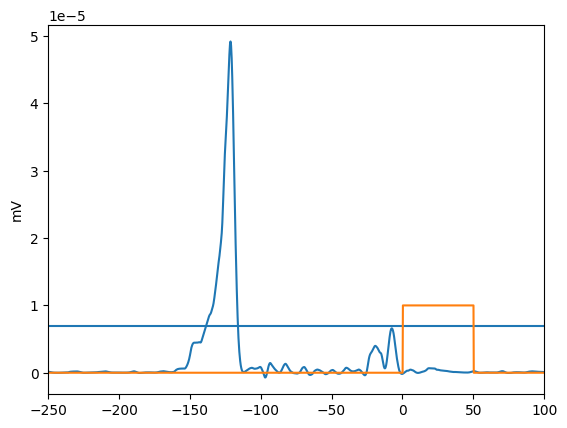

In [31]:
n_epoch = 4
plt.plot(time, tkeo_epochs[n_epoch]); #np.mean(bas_epochs, axis=0));
# plt.plot(time, -bas_epochs[n_epoch]); #np.mean(bas_epochs, axis=0));
# plt.plot(time, np.mean(tkeo_epochs[1:], axis=0)); #np.mean(bas_epochs, axis=0));

plt.axhline(7.000000000000001e-09*1e3)
plt.xlim(-250, 100)
plt.ylabel("mV")
plt.plot(time, trig_epochs[n_epoch] * 1e-5);

In [67]:
bas_epochs < -0.0005

array([[False, False, False, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(15, 4000))

In [9]:
epochs

array([[0.01667144, 0.01668237, 0.01668965, ..., 0.0166459 , 0.01665386,
        0.01666206],
       [0.01670005, 0.01669678, 0.01669434, ..., 0.01669668, 0.01669883,
        0.0167019 ],
       [0.01661499, 0.0165998 , 0.01659482, ..., 0.01659477, 0.01659868,
        0.01659985],
       ...,
       [0.0163397 , 0.01632876, 0.01631396, ..., 0.01633115, 0.01632646,
        0.01632749],
       [0.01621782, 0.01621714, 0.01621221, ..., 0.01622549, 0.01622432,
        0.01621997],
       [0.01616821, 0.01615737, 0.01614927, ..., 0.01617622, 0.01618447,
        0.01619619]], shape=(15, 400))